In [109]:
#imports

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Input, Embedding, Flatten, Concatenate, Dropout
from keras.optimizers import Adam
from keras.models import Model



In [110]:
#getting data
players_valuations = pd.read_csv('archive/player_valuations.csv')

players = pd.read_csv('archive/players.csv')


#merging data

players_valuations = pd.merge(players_valuations, players, on='player_id', how='left')


#data cleaning

players_valuations.drop_duplicates(subset=['player_id'], inplace=True)

players_valuations.info()


<class 'pandas.core.frame.DataFrame'>
Index: 31990 entries, 0 to 435442
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             31990 non-null  int64  
 1   date                                  31990 non-null  object 
 2   market_value_in_eur_x                 31990 non-null  int64  
 3   current_club_name_x                   31990 non-null  object 
 4   current_club_id_x                     31988 non-null  float64
 5   player_club_domestic_competition_id   24993 non-null  object 
 6   first_name                            29916 non-null  object 
 7   last_name                             31955 non-null  object 
 8   name                                  31955 non-null  object 
 9   last_season                           31955 non-null  float64
 10  current_club_id_y                     31955 non-null  float64
 11  player_code        

In [111]:
#calc age from date_of_birth
players_valuations['age'] = (pd.to_datetime('now') - pd.to_datetime(players_valuations['date_of_birth'])).dt.days // 365

#if foot is right, then foot is 0, if foot is left, then foot is 1, if foot is both, then foot is 2
players_valuations['foot'] = players_valuations['foot'].map({'right': 0, 'left': 1, 'both': 2})




In [112]:
#merge with appearances.csv
appearances = pd.read_csv('archive/appearances.csv')

appearances = appearances[['player_id','goals','assists','yellow_cards','red_cards','minutes_played']]

players_valuations = pd.merge(players_valuations, appearances, on='player_id', how='left')

In [113]:
#remove the columns ending in _y
players_valuations.drop(columns=[col for col in players_valuations.columns if col.endswith('_y')], inplace=True)


#rename the columns
players_valuations.rename(columns={col: col.replace('_x', '') for col in players_valuations.columns if col.endswith('_x')}, inplace=True)

players_valuations.info()

#drop rows with missing values in specific columns
players_valuations.dropna(subset=['market_value_in_eur', 'age', 'height_in_cm', 'foot', 'current_club_id', 'country_of_citizenship', 'position','goals','assists','yellow_cards','red_cards','minutes_played'], inplace=True)





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737263 entries, 0 to 1737262
Data columns (total 31 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   player_id                             int64  
 1   date                                  object 
 2   market_value_in_eur                   int64  
 3   current_club_name                     object 
 4   current_club_id                       float64
 5   player_club_domestic_competition_id   object 
 6   first_name                            object 
 7   last_name                             object 
 8   name                                  object 
 9   last_season                           float64
 10  player_code                           object 
 11  country_of_birth                      object 
 12  city_of_birth                         object 
 13  country_of_citizenship                object 
 14  date_of_birth                         object 
 15  sub_position   

In [114]:
le_country = LabelEncoder()
players_valuations['country_id'] = le_country.fit_transform(players_valuations['country_of_citizenship'])

le_position = LabelEncoder()
players_valuations['position_id'] = le_position.fit_transform(players_valuations['position'])

Epoch 1/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 17s 404us/step - loss: 5.1968 - val_loss: 1.3635
Epoch 2/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 389us/step - loss: 1.4013 - val_loss: 1.2573
Epoch 3/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 384us/step - loss: 1.3263 - val_loss: 1.2071
Epoch 4/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 382us/step - loss: 1.2970 - val_loss: 1.1924
Epoch 5/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 377us/step - loss: 1.2792 - val_loss: 1.1786
Epoch 6/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 376us/step - loss: 1.2749 - val_loss: 1.1551
Epoch 7/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 376us/step - loss: 1.2614 - val_loss: 1.1393
Epoch 8/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 387us/step - loss: 1.2547 - val_loss: 1.1548
Epoch 9/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 371us/step - loss: 1.2485 - val_loss: 1.1380
Epoch 10/10
42117/42117 ━━━━━━━━━━━━━━━━━━━━ 16s 370us/step - loss: 1.2458 - val_loss: 1.1218
10530/10530 ━━━━━━━━━━━━━━━━━━━━ 2s 230us/step
MSE: 5751389392224.97


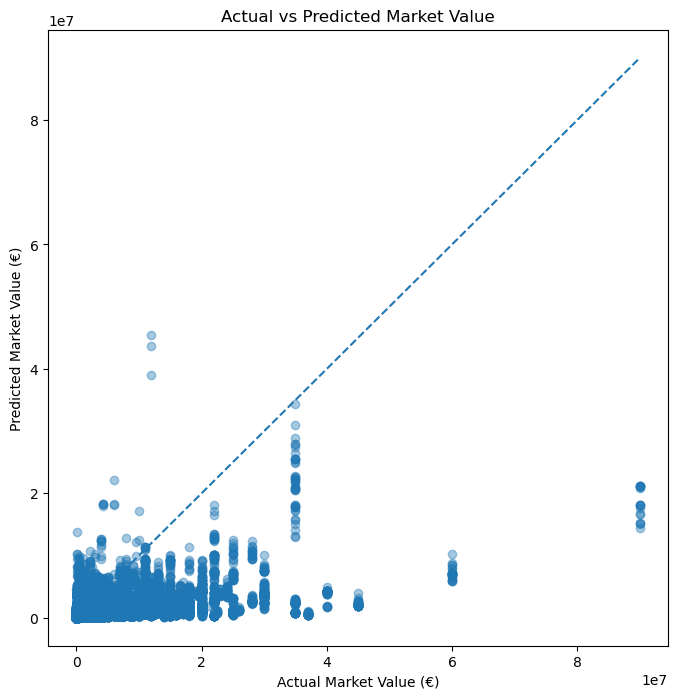

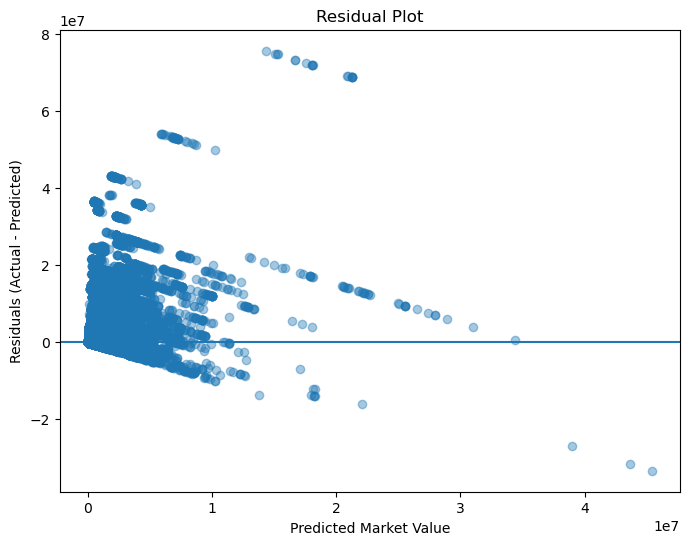

/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_12594/2529533387.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby("bin").mean()


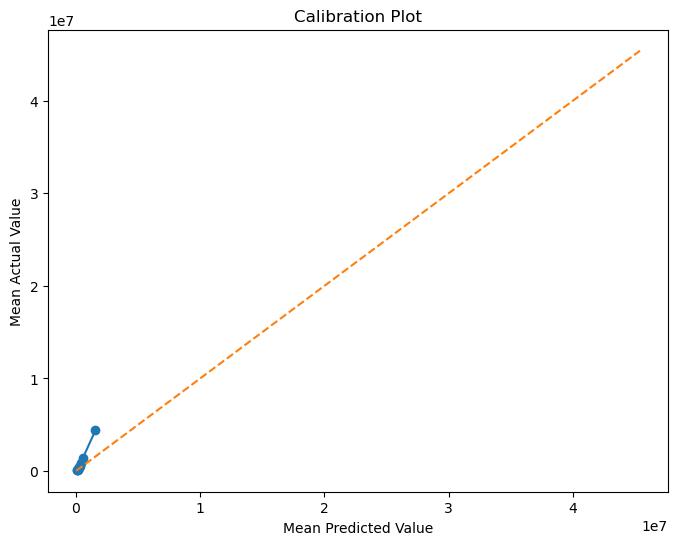

In [115]:
#proof of concept model predictining market value
# numerical
X_num = players_valuations[['age','height_in_cm','foot','current_club_id','goals','assists','yellow_cards','red_cards','minutes_played']]

# categorical
country = players_valuations['country_id']
position = players_valuations['position_id']

y = np.log1p(players_valuations['market_value_in_eur'])
# scale numeric
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

# split
Xn_train, Xn_test, c_train, c_test, p_train, p_test, y_train, y_test = train_test_split(
    X_num, country, position, y, test_size=0.2, random_state=42
)

# reshape for embedding
c_train = np.array(c_train).reshape(-1,1)
c_test = np.array(c_test).reshape(-1,1)
p_train = np.array(p_train).reshape(-1,1)
p_test = np.array(p_test).reshape(-1,1)

# inputs
num_input = Input(shape=(Xn_train.shape[1],))
country_input = Input(shape=(1,))
position_input = Input(shape=(1,))

country_embedding = Embedding(
    input_dim=len(le_country.classes_),  # number of countries
    output_dim=8                 # embedding size
)(country_input)

position_embedding = Embedding(
    input_dim=len(le_position.classes_),  # number of positions
    output_dim=8                 # embedding size
)(position_input)

country_embedding = Flatten()(country_embedding)
position_embedding = Flatten()(position_embedding)

x = Concatenate()([num_input, country_embedding, position_embedding])
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1)(x)

model = Model(inputs=[num_input, country_input, position_input], outputs=output)
model.compile(optimizer='adam', loss='mse')

# train
model.fit(
    [Xn_train, c_train, p_train],
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=([Xn_test, c_test, p_test], y_test)
)

# predict
y_pred_log = model.predict([Xn_test, c_test, p_test])

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

#mse and r2 score
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

import matplotlib.pyplot as plt
import numpy as np



#plotting
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.4)
# perfect prediction line
max_val = max(y_true.max(), y_pred.max())
min_val = min(y_true.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel("Actual Market Value (€)")
plt.ylabel("Predicted Market Value (€)")
plt.title("Actual vs Predicted Market Value")
plt.show()

residuals = y_true - y_pred.flatten()
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted Market Value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()




df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred.flatten()
})
# bin predictions
df["bin"] = pd.qcut(df["y_pred"], q=10)
calibration = df.groupby("bin").mean()
plt.figure(figsize=(8,6))
plt.plot(calibration["y_pred"], calibration["y_true"], marker='o')
plt.plot([df.y_pred.min(), df.y_pred.max()],
         [df.y_pred.min(), df.y_pred.max()],
         linestyle="--")
plt.xlabel("Mean Predicted Value")
plt.ylabel("Mean Actual Value")
plt.title("Calibration Plot")
plt.show()